# K-Nearest Neighbors (KNN) Regression for Airbnb Price Prediction

This notebook applies **K-Nearest Neighbors (KNN) regression** to our MSE 446 project dataset to predict **average Airbnb price (`rate_avg`)** using listing, host, location, amenity, review, seasonal, and market-related features.

In class, KNN was introduced as a method that finds the **k nearest observations** in the training set and uses those neighbors to make a prediction. For classification, the prediction is a class label based on nearby observations. In our project, we are using the **regression version of KNN**, so the model predicts a **numeric price** by averaging the target values of similar listings.

This fits our project well because the pricing question is naturally similarity-based: if two listings are similar in terms of location, size, amenities, room type, and reviews, then their prices should also be similar. That makes KNN a reasonable model to test alongside the other regression models in our project.

The notebook follows the workflow emphasized in MSE 446:
1. prepare and inspect the data,
2. select appropriate predictors,
3. split into training and test sets,
4. scale features properly for a distance-based model,
5. tune the model using cross-validation,
6. evaluate the final model on unseen test data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional: uncomment later if you want to test PCA
# from sklearn.decomposition import PCA


## Load and inspect the cleaned dataset

We begin by loading the cleaned project dataset and checking its shape and first few rows. This matches the course emphasis on understanding the data before fitting a model.


In [2]:

# Load dataset
df = pd.read_csv("Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv")

print("Dataset shape:", df.shape)
print("First 5 rows:")
display(df.head())


Dataset shape: (3225, 71)
First 5 rows:


,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [3]:

# Define target and selected predictors
target_col = "rate_avg"

features_to_drop = ['listing_type_Private room in bungalow', 'month', 'is_winter', 'is_spring', 'is_summer', 'is_fall', 'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room', 'listing_type_Private room in loft']

selected_features = [col for col in df.columns if col not in features_to_drop + [target_col]]

print("Number of selected predictors:", len(selected_features))
print(selected_features)

X = df[selected_features].copy()
y = df[target_col].copy()


Number of selected predictors: 60
['photos_count', 'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'min_nights', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'num_public_holidays', 'num_major_events', 'non_resident_visitors', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_march', 'is_may', 'is_november', 'is_october', 'is_september', 'has_free_parking', 'has_gym', 'has_pool', 'listing_type_Entire condo', 'listing_type_Entire condominium', 'listing_type_Entire guest suite', 'listing_type_Entire guesthouse', 'listing_type_Entire home', 'listing_type_Entire house', 'listing_type_Entire loft', 'listing_type_Entire place', 'listing_type_Entire rental unit', 'listing_type_Entire townhouse', 'listing_type_Private room', 'listing_type_Private room in condo', 'listing_type_Private room in cottage', 'listing_t

## Why these 60 features?

For our project, the goal is not just to run KNN mechanically. We want the distance between two listings to be **meaningful**. Since KNN is a **distance-based method**, too many irrelevant, redundant, or extremely sparse variables can make “nearest neighbors” less informative.

That is why we kept 60 features that are more directly connected to Airbnb pricing, including:
- **listing characteristics** such as guests, bedrooms, beds, baths, and minimum nights,
- **location variables** such as latitude and longitude,
- **amenities** such as free parking, gym, and pool,
- **review and rating information**,
- **listing and room type indicators**,
- **seasonal/month indicators** that capture time effects without over-duplicating them.

We removed 10 columns because they were less useful for a KNN pricing model:

1. **`listing_type_Private room in bungalow`**  
   This column is constant in the dataset, so it adds no information and cannot help distinguish neighbors.

2. **`listing_type_Private room in loft`**  
   This column is extremely sparse, so it is unlikely to help define stable neighborhoods in feature space.

3. **`month`**  
   We already have one-hot encoded month indicators (such as `is_april`, `is_may`, etc.), so keeping the raw `month` column would be redundant.

4. **`is_winter`, `is_spring`, `is_summer`, `is_fall`**  
   These seasonal indicators overlap with the month dummy variables. Because KNN uses distance directly, keeping both can overweight the same time-related effect.

5. **`Hotel_Occupancy_Percentage`, `Average_Daily_Rate`, `Revenue_Per_Available_Room`**  
   These are broader market indicators. They may contain some signal, but in this dataset they vary at a coarse monthly level and are weaker for defining listing-level similarity than the property, review, amenity, and location variables that we kept.

This feature selection step also ties back to course content on **data preparation, model selection, and generalization**. A simpler and more relevant feature set helps reduce noise, improve interpretability, and give KNN a better chance of identifying truly comparable listings.


In [4]:
# Document the 10 removed columns and why they were excluded
dropped_feature_reasons = pd.DataFrame({
    "Dropped Feature": [
        "listing_type_Private room in bungalow",
        "listing_type_Private room in loft",
        "month",
        "is_winter",
        "is_spring",
        "is_summer",
        "is_fall",
        "Hotel_Occupancy_Percentage",
        "Average_Daily_Rate",
        "Revenue_Per_Available_Room"
    ],
    "Reason for Removal": [
        "Constant column (all zeros), so it adds no information for KNN.",
        "Extremely sparse category, so it is unlikely to define stable neighborhoods.",
        "Redundant with one-hot encoded month variables already in the dataset.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Coarse market-level feature; weaker than listing-level similarity variables for KNN.",
        "Coarse market-level feature; weaker than listing-level similarity variables for KNN.",
        "Coarse market-level feature; weaker than listing-level similarity variables for KNN."
    ]
})

display(dropped_feature_reasons)


,Dropped Feature,Reason for Removal
0,listing_type_Private room in bungalow,"Constant column (all zeros), so it adds no inf..."
1,listing_type_Private room in loft,"Extremely sparse category, so it is unlikely t..."
2,month,Redundant with one-hot encoded month variables...
3,is_winter,Redundant with month dummy variables already c...
4,is_spring,Redundant with month dummy variables already c...
5,is_summer,Redundant with month dummy variables already c...
6,is_fall,Redundant with month dummy variables already c...
7,Hotel_Occupancy_Percentage,Coarse market-level feature; weaker than listi...
8,Average_Daily_Rate,Coarse market-level feature; weaker than listi...
9,Revenue_Per_Available_Room,Coarse market-level feature; weaker than listi...


In [5]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2580, 60)
X_test shape: (645, 60)
y_train shape: (2580,)
y_test shape: (645,)


## KNN Modeling Approach

Following the workflow used in class, we first split the data into training and test sets, then define the model, fit it on the training data, and evaluate it on unseen data.

We use a **pipeline** so that:
1. the train/test split happens before model fitting,
2. feature scaling is learned only from the training data,
3. cross-validation stays clean,
4. data leakage is avoided.

This matters a lot for KNN because the model is entirely based on distance. If scaling were done on the full dataset before splitting, information from the test set could leak into the training process, which would make the results look better than they really are.

This also connects directly to course topics on **proper training/testing procedures**, **cross-validation**, and **generalization**.


In [6]:
# Candidate values to test
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 31]
weight_options = ["uniform", "distance"]
p_values = [1, 2]  # p=1 Manhattan, p=2 Euclidean

# Store all loop results here
loop_results = []

for weights in weight_options:
    for p in p_values:
        for k in k_values:
            knn_pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsRegressor(
                    n_neighbors=k,
                    weights=weights,
                    p=p
                ))
            ])

            # Cross-validated RMSE on the training data
            cv_rmse_scores = -cross_val_score(
                knn_pipeline,
                X_train,
                y_train,
                cv=5,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1
            )

            loop_results.append({
                "k": k,
                "weights": weights,
                "p": p,
                "distance_metric": "Manhattan" if p == 1 else "Euclidean",
                "cv_rmse_mean": cv_rmse_scores.mean(),
                "cv_rmse_std": cv_rmse_scores.std()
            })

results_df = pd.DataFrame(loop_results).sort_values(
    by="cv_rmse_mean", ascending=True
).reset_index(drop=True)

display(results_df.head(10))


,k,weights,p,distance_metric,cv_rmse_mean,cv_rmse_std
0,9,distance,1,Manhattan,37.325422,0.920993
1,7,distance,1,Manhattan,37.656201,0.620908
2,11,distance,1,Manhattan,37.889661,0.939512
3,5,distance,1,Manhattan,38.311846,1.097779
4,7,uniform,1,Manhattan,38.373752,0.443023
5,9,uniform,1,Manhattan,38.408622,0.934248
6,5,uniform,1,Manhattan,38.701282,1.014770
7,13,distance,1,Manhattan,38.773752,1.332207
8,11,uniform,1,Manhattan,39.466440,0.946136
9,15,distance,1,Manhattan,39.853743,1.734233


In [7]:
# Select the best parameter combination from the loop results
best_row = results_df.iloc[0]

best_k = int(best_row["k"])
best_weights = best_row["weights"]
best_p = int(best_row["p"])
best_distance = best_row["distance_metric"]

print("Best parameters found from manual tuning loop:")
print(f"k = {best_k}")
print(f"weights = {best_weights}")
print(f"distance metric = {best_distance} (p = {best_p})")

Best parameters found from manual tuning loop:
k = 9
weights = distance
distance metric = Manhattan (p = 1)


In [8]:
# Fit the final KNN model using the best parameters found above
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=best_k,
        weights=best_weights,
        p=best_p
    ))
])

best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

# Evaluate on the held-out test set
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R^2:", r2)


Test MSE: 1306.5696546477802
Test RMSE: 36.14650266136103
Test MAE: 22.79847370766862
Test R^2: 0.8772143548873329


In [9]:
# Cross-validated RMSE scores for the final selected model on the training data
final_cv_rmse_scores = -cross_val_score(
    best_knn,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

final_cv_mse_scores = final_cv_rmse_scores ** 2

print("Fold RMSE values:", final_cv_rmse_scores)
print("Mean CV RMSE:", final_cv_rmse_scores.mean())
print("Std CV RMSE:", final_cv_rmse_scores.std())
print("Mean CV MSE:", final_cv_mse_scores.mean())


Fold RMSE values: [36.45772083 38.11612043 37.68081525 36.0247675  38.34768586]
Mean CV RMSE: 37.32542197540808
Std CV RMSE: 0.9209928562209392
Mean CV MSE: 1394.035353483486


In [10]:
# Summary of KNN regression results for the project dataset
results_summary = pd.DataFrame({
    "Metric": ["Best CV RMSE", "Mean CV MSE", "Test MSE", "Test RMSE", "Test MAE", "Test R^2"],
    "Value": [
        results_df.iloc[0]["cv_rmse_mean"],
        final_cv_mse_scores.mean(),
        mse,
        rmse,
        mae,
        r2
    ]
})

display(results_summary)


,Metric,Value
0,Best CV RMSE,37.325422
1,Mean CV MSE,1394.035353
2,Test MSE,1306.569655
3,Test RMSE,36.146503
4,Test MAE,22.798474
5,Test R^2,0.877214


## Model diagnostics and interpretation

The plots below help us interpret how the tuned KNN model behaves.

- The **actual vs. predicted** plot shows how closely the model’s predictions match the true average prices on the held-out test set.  
- The **CV RMSE vs. k** plot shows how model performance changes as the number of neighbors changes under different weighting and distance settings.

Together, these plots connect back to the course discussion of choosing **k** carefully: small values can be sensitive to noise, while large values may smooth the predictions too much by averaging over listings that are not truly similar.


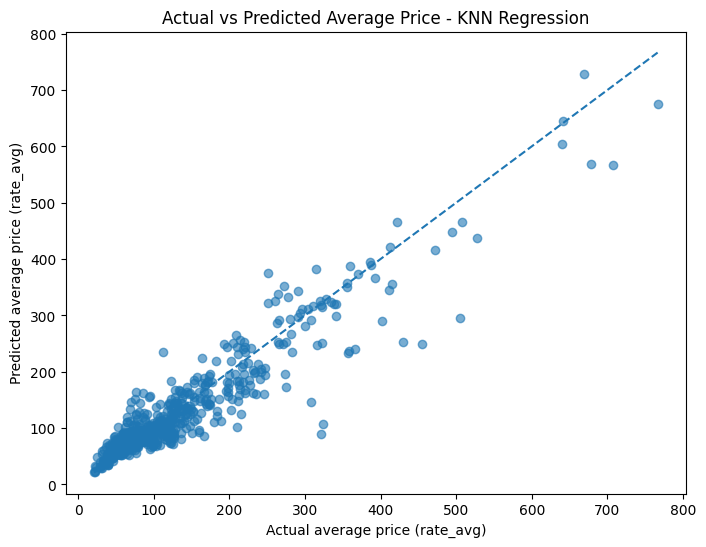

In [11]:

# Plot actual vs predicted
# using the best K value found in loop (cross-validation)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual average price (rate_avg)")
plt.ylabel("Predicted average price (rate_avg)")
plt.title("Actual vs Predicted Average Price - KNN Regression")
plt.show()


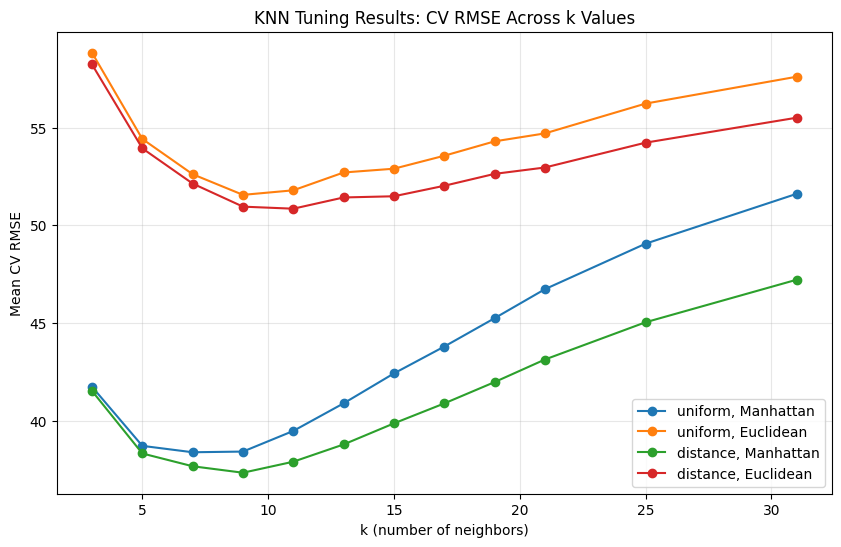

In [12]:
# Plot CV RMSE vs k for each weighting / distance setting
plt.figure(figsize=(10, 6))

for weights in weight_options:
    for p in p_values:
        subset = results_df[
            (results_df["weights"] == weights) &
            (results_df["p"] == p)
        ].sort_values("k")

        label = f"{weights}, {'Manhattan' if p == 1 else 'Euclidean'}"
        plt.plot(subset["k"], subset["cv_rmse_mean"], marker="o", label=label)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean CV RMSE")
plt.title("KNN Tuning Results: CV RMSE Across k Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final takeaway

This notebook applies KNN regression in a way that is consistent with MSE 446 course principles:
- relevant feature selection,
- train/test separation,
- scaling for a distance-based model,
- cross-validation for tuning,
- and final evaluation on unseen data.

If KNN performs competitively against the other group models, that would suggest that Airbnb price can be estimated effectively by comparing each listing to similar nearby listings in feature space. If it underperforms, that is still a useful result: it would suggest that a purely distance-based approach is less effective than models that capture global linear trends or more complex nonlinear interactions.
